# Regresión Lineal: De la Simple a la Múltiple

En este cuaderno aprenderás desde cero cómo funciona la regresión lineal, comenzando por la simple y avanzando hacia la múltiple, siempre con ejemplos prácticos en Python.

## 1. ¿Qué es la regresión lineal simple?

La regresión lineal simple es una técnica estadística que permite modelar la relación entre una variable independiente $X$ y una variable dependiente $Y$ mediante una recta:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

- $\beta_0$ es el intercepto (valor de $Y$ cuando $X=0$)
- $\beta_1$ es la pendiente (cuánto cambia $Y$ por cada unidad que cambia $X$)
- $\varepsilon$ es el error o residuo

### Ejemplo práctico: Regresión lineal simple en Python

Supongamos que queremos predecir las ventas de helados ($Y$) a partir de la temperatura ($X$).

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     74.08
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.36e-09
Time:                        16:49:54   Log-Likelihood:                -107.73
No. Observations:                  30   AIC:                             219.5
Df Residuals:                      28   BIC:                             222.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      59.5329     12.308      4.837      

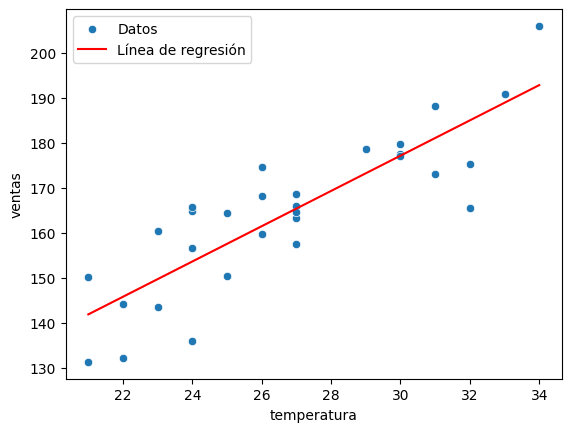

In [9]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# Datos simulados
np.random.seed(42)
n = 30
X1 = np.random.randint(20, 35, n)  # Temperatura

# Relación: ventas = 5*temp + 30 (sin ruido)",
Y = 5*X1 + 30 + np.random.normal(0, 10, n)  # Agregamos algo de ruido

df = pd.DataFrame({'ventas': Y, 'temperatura': X1})

modelo = ols('ventas ~ temperatura', data=df).fit()

print(modelo.summary())

# Graficamos los datos y la línea de regresión usando seaboad

sns.scatterplot(x='temperatura', y='ventas', data=df, label='Datos')
sns.lineplot(x='temperatura', y=modelo.fittedvalues, color='red', label='Línea de regresión', data=df)
plt.show()


## 2. ¿Por qué pasar a regresión múltiple?

La regresión lineal simple es útil cuando solo hay una variable independiente, pero en la vida real, los fenómenos suelen depender de varios factores. Aquí es donde entra la **regresión lineal múltiple**.

**Ejemplo:** Las ventas de un producto pueden depender de la temporada, el precio, la competencia, campañas de marketing, etc.

La regresión múltiple permite modelar una variable dependiente continua $Y$ usando varias variables independientes:

$$
Y=\beta_0+\beta_1X_1+\beta_2X_2+\cdots+\beta_nX_n+\varepsilon
$$

**Ejemplo conceptual:**

- $Y$ = clics en sitio web
- $X_1$ = cantidad de personas en el anuncio
- $X_2$ = longitud del anuncio

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2
$$


## 3. Interpretación de los coeficientes en regresión múltiple

Cada coeficiente ($\beta_i$) indica el cambio esperado en $Y$ cuando la variable $X_i$ aumenta en una unidad, manteniendo las demás variables constantes.

Por ejemplo, si el coeficiente de temperatura es 10, significa que por cada grado extra, las ventas aumentan en 10 unidades, suponiendo que la publicidad no cambia.

## 4. Variables categóricas y One-Hot Encoding

En regresión múltiple, muchas veces trabajamos con variables **categóricas** (por ejemplo, tipo de anuncio, plataforma, color). Los modelos de regresión solo aceptan números, por lo que debemos transformar estas categorías en variables binarias usando **One-Hot Encoding**.

**Ejemplo:**
- Plataforma: A, B, C
- Se crean variables binarias: $X_A$, $X_B$ (la categoría C es la base)

| Servicio | $X_A$ | $X_B$ |
|----------|-------|-------|
| A        | 1     | 0     |
| B        | 0     | 1     |
| C        | 0     | 0     |

Esto permite medir el impacto de cada categoría en el modelo. Si incluyéramos todas las dummies, se produciría **multicolinealidad perfecta** (trampa de variables dummy), por eso siempre se elimina una categoría y se usa como referencia.

En Pandas, se puede hacer con:

```python
pd.get_dummies(df, drop_first=True)
```


## 5. Supuestos de la regresión lineal múltiple

Para que los resultados sean confiables, el modelo debe cumplir ciertos supuestos:

1. **Linealidad**: Relación lineal entre cada predictor y la variable objetivo.
2. **Independencia**: Las observaciones deben ser independientes entre sí.
3. **Normalidad de residuos**: Los errores deben distribuirse normalmente.
4. **Homoscedasticidad**: Varianza constante de los errores.
5. **No multicolinealidad**: Los predictores no deben estar altamente correlacionados entre sí.

La validación de estos supuestos es clave para interpretar correctamente los resultados.

En regresión múltiple, además de los supuestos clásicos (linealidad, independencia, normalidad de residuos, homocedasticidad), se suma **no multicolinealidad**: las variables independientes no deben estar altamente correlacionadas entre sí.

**Ejemplo:**
- Seguidores en redes sociales y reproducciones en plataformas musicales suelen estar muy correlacionados.



### ¿Por qué es un problema?
- Coeficientes inestables
- Interpretación difícil
- Errores estándar altos
- Variables importantes pueden parecer no significativas


### ¿Cómo detectarla?

- Visual: matriz de dispersión (`sns.pairplot(df)`)
- Matemática: Variance Inflation Factor (VIF)

```python
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[['col_1', 'col_2', 'col_3']]
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(list(zip(X.columns, vif)))
```

| VIF   | Interpretación   |
| ----- | ---------------- |
| 1     | Sin colinealidad |
| 1 - 5 | Moderada         |
| > 5   | Alta             |
| > 10  | Muy problemática |




### Soluciones a la multicolinealidad
1. Eliminar variables redundantes
2. Combinar variables correlacionadas
3. Usar técnicas de regularización 
   - Ridge 
   - Lasso
   - Análisis de componentes principales (PCA)
4. Recalcular VIF tras los cambios



**Consideración:**  
Si el objetivo es la interpretación, la multicolinealidad es un problema serio. Si solo buscas predicción, a veces puede tolerarse si mejora el desempeño.

Un buen modelo no solo ajusta bien los datos, también cumple los supuestos y produce resultados confiables.

## 6 Ejemplo codigo Regresion multiple

Antes vimos las ventas de helados con respecto a la temperatura , pero ahora agregamos una variable mas ej la publicidad

In [10]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# Datos simulados
np.random.seed(42)
n = 30
X1 = np.random.randint(20, 35, n)  # Temperatura
X2 = np.random.randint(1, 8, n)    # Gastos en publicidad (miles de $)

# Relación: ventas = 5*temp + 15*publi + 30 + ruido
Y = 5*X1 + 15*X2 + 30 + np.random.normal(0, 10, n)

# Relación: ventas = 5*temp + 15*publi + 30 (sin ruido)",
Y = 5*X1 + 15*X2 + 30
# DataFrame
df = pd.DataFrame({'ventas': Y, 'temperatura': X1, 'publicidad': X2})

# Modelo con fórmula
modelo = ols('ventas ~ temperatura + publicidad', data=df).fit()

# Resumen del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.946e+30
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:43   Log-Likelihood:                 859.46
No. Observations:                  30   AIC:                            -1713.
Df Residuals:                      27   BIC:                            -1709.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      30.0000   1.35e-13   2.23e+14      

### Visualización de los datos y el ajuste del modelo

A continuación, graficamos los datos simulados y la predicción del modelo para ver el ajuste en 3D y en 2D (proyecciones).

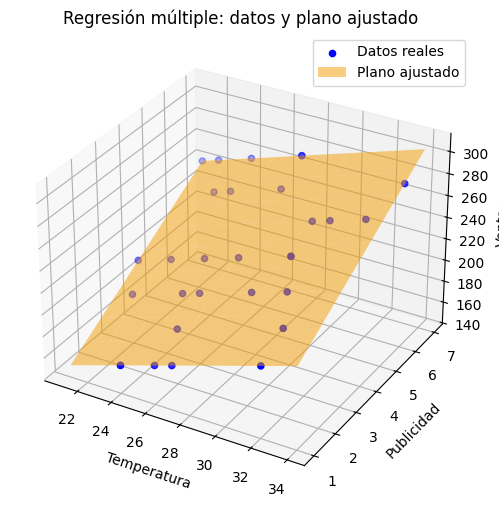

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Gráfico 3D de los datos y el plano ajustado

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['temperatura'], df['publicidad'], df['ventas'], color='blue', label='Datos reales')

# Crear malla para el plano
x_surf, y_surf = np.meshgrid(np.linspace(df['temperatura'].min(), df['temperatura'].max(), 10),

                        np.linspace(df['publicidad'].min(), df['publicidad'].max(), 10))

z_surf = modelo.params['Intercept'] + modelo.params['temperatura'] * x_surf + modelo.params['publicidad'] * y_surf

ax.plot_surface(x_surf, y_surf, z_surf, color='orange', alpha=0.5, label='Plano ajustado')


ax.set_xlabel('Temperatura')
ax.set_ylabel('Publicidad')
ax.set_zlabel('Ventas')

plt.title('Regresión múltiple: datos y plano ajustado')
plt.legend()
plt.show()

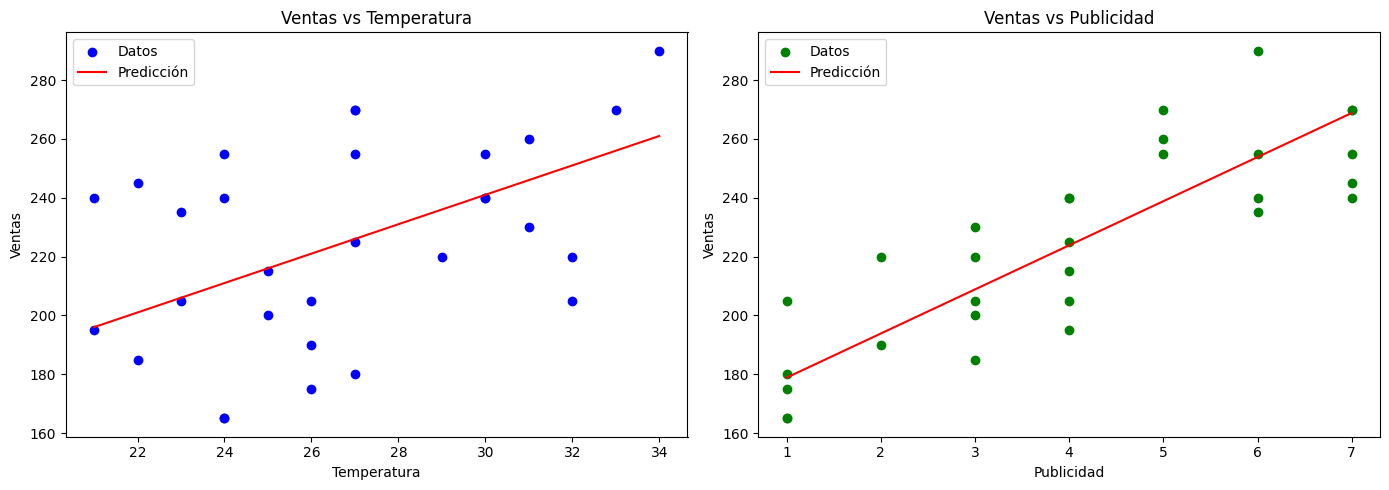

In [12]:
# Gráficos 2D: Ventas vs Temperatura y Ventas vs Publicidad

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
# Ventas vs Temperatura

axs[0].scatter(df['temperatura'], df['ventas'], color='blue', label='Datos')
axs[0].set_xlabel('Temperatura')
axs[0].set_ylabel('Ventas')
axs[0].set_title('Ventas vs Temperatura')

# Línea de predicción manteniendo publicidad fija en su media

temp_range = np.linspace(df['temperatura'].min(), df['temperatura'].max(), 30)
ventas_pred_temp = modelo.params['Intercept'] + modelo.params['temperatura'] * temp_range + modelo.params['publicidad'] * df['publicidad'].mean()
axs[0].plot(temp_range, ventas_pred_temp, color='red', label='Predicción')
axs[0].legend()

# Ventas vs Publicidad

axs[1].scatter(df['publicidad'], df['ventas'], color='green', label='Datos')
axs[1].set_xlabel('Publicidad')
axs[1].set_ylabel('Ventas')
axs[1].set_title('Ventas vs Publicidad')

# Línea de predicción manteniendo temperatura fija en su media

publi_range = np.linspace(df['publicidad'].min(), df['publicidad'].max(), 30)

ventas_pred_publi = modelo.params['Intercept'] + modelo.params['temperatura'] * df['temperatura'].mean() + modelo.params['publicidad'] * publi_range

axs[1].plot(publi_range, ventas_pred_publi, color='red', label='Predicción')
axs[1].legend()

plt.tight_layout()
plt.show()

Puntos Relevantes

- **Interpretación de coeficientes**: Cada β representa el cambio esperado en la variable dependiente por cada unidad de cambio en la variable independiente correspondiente, manteniendo las demás constantes.
- **Variables binarias**: Permiten analizar el efecto de factores cualitativos (ejemplo: si hay o no publicidad).
- **Términos de interacción**: Capturan situaciones donde el efecto de una variable depende del valor de otra.
- **Importancia del contexto**: No solo importa el ajuste del modelo, sino también la interpretación y la comunicación de los resultados para la toma de decisiones.

## Conclusiones

La regresión múltiple es una herramienta poderosa para entender fenómenos complejos y reales, ya que permite:

- Estimar el efecto individual de cada variable, controlando por las demás.
- Incluir variables categóricas y analizar su impacto.
- Incorporar términos de interacción para modelar relaciones más complejas.
- Traducir los resultados en insights accionables para el negocio o la investigación.

___

# Regresión lineal múltiple

A lo largo de los siguientes ejercicios, aprenderás a usar Python para construir un modelo de regresión lineal múltiple. Antes de comenzar con este ejercicio de programación, recomendamos encarecidamente ver la conferencia en video y completar la IVQ para los temas asociados.

Toda la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.

A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno. Antes de comenzar con los ejercicios y analizar los datos, necesitamos importar todas las bibliotecas y extensiones requeridas para este ejercicio de programación. A lo largo del curso, utilizaremos pandas y statsmodels para operaciones, y seaborn para gráficos.

## Importaciones relevantes

In [ ]:
# Import packages
import pandas as pd
import seaborn as sns

In [ ]:
# Load dataset
penguins = sns.load_dataset("penguins", cache=False)

# Examine first 5 rows of dataset
penguins.head()

**Nota:** Recuerda que el valor predeterminado de `head()` es mostrar las primeras 5 filas. Si cambias el valor de `n`, puedes mostrar más filas. Por ejemplo, el comando `penguins.head(3)` mostrará 3 filas.

De las primeras 5 filas del conjunto de datos, podemos ver que hay varias columnas disponibles: `species`, `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, y `sex`. También parece haber algunos datos faltantes.

## Limpieza de datos (no mostrada en el video)

Limpia el conjunto de datos seleccionando columnas específicas, renombrando columnas, eliminando filas con valores faltantes y restableciendo el índice. Para los propósitos de este ejercicio, nos centraremos en las columnas `body_mass_g`, `bill_length_mm`, `sex` y `species`. En un entorno de trabajo, deberás tomar decisiones cuidadosas sobre qué variables incluir o excluir. Más adelante en este curso, cubriremos algunas de las técnicas para la selección de variables. Por ahora, nuestro enfoque está solo en construir el modelo, y evaluar e interpretar los resultados.

**Nota:** Para los propósitos de este ejercicio, no examinamos los datos minuciosamente antes de eliminar filas con datos faltantes. En un entorno de trabajo, normalmente examinarías los datos más a fondo antes de decidir cómo manejar los datos faltantes (es decir, rellenar, eliminar, etc.). Por favor, consulta el contenido del programa anterior si necesitas revisar cómo manejar los datos faltantes.


In [ ]:
# Subset data
penguins = penguins[["body_mass_g", "bill_length_mm", "sex", "species"]]

# Rename columns
penguins.columns = ["body_mass_g", "bill_length_mm", "gender", "species"]

# Drop rows with missing values
penguins.dropna(inplace=True)

# Reset index
penguins.reset_index(inplace=True, drop=True)

Puedes revisar la documentación para [`dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) y [`reset_index()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html). En resumen, la función `dropna()` por defecto elimina cualquier fila con cualquier valor faltante en cualquiera de las columnas. La función `reset_index()` restablece los valores del índice para las filas en el DataFrame. Normalmente, usas `reset_index()` después de haber terminado de manipular el conjunto de datos. Al establecer `inplace=True`, no crearás un nuevo objeto DataFrame. Al establecer `drop=True`, no insertarás una nueva columna de índice en el objeto DataFrame.

In [ ]:
# Examine first 5 rows of data
penguins.head()

## Crear muestra de reserva


Anteriormente, aprendiste sobre cómo crear una muestra de reserva para probar y evaluar mejor los resultados de tu modelo de regresión. Para hacer esto más fácilmente en Python, debes subconjuntar tus variables x e y, importar la función `train_test_split` de `sci-kit learn`, y luego usar la función. Por favor, revisa el contenido del curso sobre muestras de reserva según sea necesario antes de continuar con el resto del cuaderno.

In [ ]:
# Subset X and y variables
penguins_X = penguins[["bill_length_mm", "gender", "species"]]
penguins_y = penguins[["body_mass_g"]]

In [ ]:
# Import train-test-split function from sci-kit learn
from sklearn.model_selection import train_test_split

**Nota:** Hemos establecido la variable `test_size` en `0.3`, lo que indica a la función qué proporción de los datos debe estar en la muestra de reserva. Además, hemos establecido la variable `random_state` igual a `42` para reproducibilidad. Si cambias el `random_state`, tus conjuntos de datos de muestra de reserva y entrenamiento serán diferentes, por lo que tu modelo puede comportarse de manera diferente.

## Construcción del modelo

Recuerda que hemos explorado el conjunto de datos de pingüinos antes. Anteriormente, usamos gráficos de dispersión para realizar análisis exploratorios de datos, y identificamos relaciones lineales entre las siguientes variables:

* longitud del pico (mm) y longitud de la aleta (mm)
* longitud del pico (mm) y masa corporal (g)
* longitud de la aleta (mm) y masa corporal (g)

En esta parte del curso, nos centraremos en entender algunas de las relaciones de las variables con la masa corporal (g). Usaremos una variable X continua, longitud del pico (mm), y las dos variables categóricas, género y especie.

Primero, tenemos que escribir la fórmula como una cadena. Recuerda que escribimos primero el nombre de la variable y, seguido de la tilde (`~`), y luego cada una de las variables X separadas por un signo más (`+`). Podemos usar `C()` para indicar una variable categórica. Esto indicará a la función `ols()` que codifique en caliente esas variables en el modelo. Por favor, revisa los materiales del curso anterior según sea necesario para repasar cómo y por qué codificamos las variables categóricas para regresión.

In [ ]:
# Write out OLS formula as a string
ols_formula = "body_mass_g ~ bill_length_mm + C(gender) + C(species)"

**Nota:** Los nombres de las variables x e y tienen que coincidir exactamente con los nombres de las columnas en el dataframe.

In [ ]:
# Import ols() function from statsmodels package
from statsmodels.formula.api import ols

Después de haber importado la función `ols()`, podemos guardar `ols_data` como un dataframe, crear el objeto `ols`, ajustar el modelo y generar estadísticas resumidas. En este punto, tendría sentido verificar las suposiciones del modelo sobre los errores (homocedasticidad y normalidad de los residuos). Por favor, revisa otros recursos en el programa según sea necesario.


In [ ]:
# Create OLS dataframe
ols_data = pd.concat([X_train, y_train], axis = 1)

# Create OLS object and fit the model
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()

## Evaluación e interpretación del modelo

Use la función `.summary()` para obtener una tabla resumen de resultados y estadísticas del modelo.

Una vez que tenemos nuestra tabla resumen, podemos interpretar y evaluar el modelo. En la mitad superior de la tabla, obtenemos varias estadísticas resumen. Nos centraremos en `R-cuadrado`, que nos indica cuánto de la variación en la masa corporal (g) es explicada por el modelo. Un `R-cuadrado` de 0.85 es bastante alto, y esto significa que el 85% de la variación en la masa corporal (g) es explicada por el modelo.

Pasando a la mitad inferior de la tabla, obtenemos los coeficientes beta estimados por el modelo y sus intervalos de confianza del 95% y valores p correspondientes. Basándonos en la columna de valores p, etiquetada como `P>|t|`, podemos decir que todas las variables X son estadísticamente significativas, ya que el valor p es menor que 0.05 para cada variable X.


In [ ]:
# Get model results
model.summary()

Podemos entonces interpretar cada uno de los coeficientes beta para cada variable X.

### C(género) - Macho
Dado el nombre de la variable, sabemos que la variable fue codificada como `Macho = 1`, `Hembra = 0`. Esto significa que las pingüinas hembras son el punto de referencia. Si todas las demás variables son constantes, entonces esperaríamos que la masa corporal de un pingüino macho sea aproximadamente 528.95 gramos más que la masa corporal de una pingüina hembra.

### C(especie) - Chinstrap y Gentoo
Dado los nombres de estas dos variables, sabemos que los pingüinos Adelie son el punto de referencia. Entonces, si comparamos un pingüino Adelie y un pingüino Chinstrap, que tienen las mismas características excepto su especie, esperaríamos que el pingüino Chinstrap tenga una masa corporal de aproximadamente 285.39 gramos menos que el pingüino Adelie. Si comparamos un pingüino Adelie y un pingüino Gentoo, que tienen las mismas características excepto su especie, esperaríamos que el pingüino Gentoo tenga una masa corporal de aproximadamente 1,081.62 gramos más que el pingüino Adelie.

### Longitud del pico (mm)
Por último, la longitud del pico (mm) es una variable continua, por lo que si comparamos dos pingüinos que tienen las mismas características, excepto que el pico de un pingüino es 1 milímetro más largo, esperaríamos que el pingüino con el pico más largo tenga 35.55 gramos más de masa corporal que el pingüino con el pico más corto.

## 7. Interpretación de resultados

- Cada coeficiente indica el cambio esperado en la variable dependiente al variar ese predictor, manteniendo los demás constantes.
- El valor p indica si el coeficiente es estadísticamente significativo.
- $R^2$ muestra la proporción de la variabilidad explicada por el modelo.

**Ejemplo:**
- Si el coeficiente de `C(sex)[T.Male]` es 528.95, los machos pesan en promedio 528.95g más que las hembras, manteniendo constantes las demás variables.
- Un $R^2$ de 0.85 indica que el modelo explica el 85% de la variabilidad en la masa corporal.


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.

Ahora entiendes cómo construir un modelo de regresión lineal múltiple con Python. En adelante, puedes comenzar a usar modelos de regresión lineal múltiple con tus propios conjuntos de datos.

## Preguntas de repaso

1. **¿Qué técnica permite transformar variables categóricas en variables binarias para usarlas en regresión?**
    - a) Regresión múltiple
    - b) R cuadrado ajustado
    - c) One-Hot Encoding
    - d) Codificación de etiquetas

2. **¿Cuál es la definición de la hipótesis de no multicolinealidad?**
    - a) Ninguna variable de predicción puede relacionarse linealmente con la variable de resultado.
    - b) No puede haber dos variables independientes altamente correlacionadas entre sí.
    - c) La variación del residuo debe ser constante o similar en todo el modelo.
    - d) Ninguna observación del conjunto de datos puede ser independiente.

3. **¿Qué estadísticos relevantes puede encontrar usando la función OLS de statsmodels?**
    - a) Valores P
    - b) Coeficientes
    - c) Factores de inflación de la varianza
    - d) Errores estándar

4. **¿Qué representa un término de interacción en regresión múltiple?**
    - a) La relación entre dos variables independientes y el cambio en la media de la variable dependiente.
    - b) El cambio en la varianza de los residuos.
    - c) La correlación entre predictores.
    - d) El valor p de la variable dependiente.

*(Respuestas: 1c, 2b, 3a-b-d, 4a)*